<img src="logo_UNSAM.jpg" align="right" width="150">

#### Análisis y Procesamiento de Señales

# *TS2 - Sistemas Lineales e Invariantes en el Tiempo*

### *Autora: Catalina Gonzalez Araujo*

### *Docentes: Mariano Llamedo Soria, David Ezequiel Benoit, Francisco Hernan Ledesma.*

# <u>**Introducción teórica**</u>

En el análisis de señales y sistemas, un aspecto fundamental es el estudio de los sistemas lineales e invariantes en el tiempo (**LTI**), ya que constituyen un modelo matemático que permite describir y predecir el comportamiento de una amplia variedad de fenómenos físicos y electrónicos. 

Estos sistemas se caracterizan por cumplir dos propiedades: 
- Linealidad: la respuesta a una combinación lineal de entradas es igual a la combinación lineal de las respuestas individuales.
- Invariancia en el tiempo: el comportamiento del sistema no depende del instante en el que se aplica la señal de entrada.

Una forma habitual de representar los sistemas *LTI* en el dominio discreto es mediante **ecuaciones en diferencias** lineales con coeficientes constantes, las cuales relacionan el valor presente de la señal de salida ($y[n]$) con combinaciones de entradas ($x[n]$) y, en algunos casos, con valores pasados de la propia salida. 

A partir de estas ecuaciones, es posible obtener la **respuesta al impulso** del sistema ($h[n]$), la cual constituye una descripción completa de su comportamiento, ya que cualquier salida puede obtenerse como la convolución entre la entrada y dicha respuesta.

Cuando decimos **convolusión** nos referimos a la operación matemática entre dos secuencias que se describe mediante la siguiente ecuación: 
$$
y[n] = x[n] * h[n] = \sum_{k = -\infty}^{\infty}x[k] \cdot h[n - k] 
$$ 

Dependiendo el comportamiento de la respuesta al impulso ($h[n]$), los sistemas se pueden clasificar en dos tipos:
- **FIR** (*Finite Impulse Response*): son sistemas cuya respuesta al impulse es finita. La salida de estos sistemas depende solo de la entrada presente y pasada. La relacion entrada-salida se representa con la siguiente ecuación: $y[n] = \sum_{k=M}^{N} b_k x[n-k]$
- **IIR** (*Infinite Impulse Response*): son sistemas que tienen una respuesta al impulso infinito. Involucra retroalimentacion de la salida, es decir que la salida depende tanto de la entrada presente y pasada como de la misma salida en tiempo pasado. La relación entrada-salida se describe como: $ y[n]= \sum_{k=0}^{M} b_k x[n-k] - \sum_{k=1}^{N} a_k y[n-k]$

# <u>**Análisis y desarrollo**</u>

En todos los experimentos realizados se trabajó con señales causales y se definieron explícitamente los parámetros de simulación: frecuencia de muestreo, cantidad de muestras y tiempo de observación. Esto aseguró la coherencia de los resultados numéricos y gráficos obtenidos. 

Para la implementación en Python se desarrollaron funciones específicas y se emplearon librerías de *Numpy* y *SciPy*, que permitieron simular los sistemas, calcular convoluciones y obtener medidas de energía y potencia de forma eficiente. 

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, unit_impulse
from scipy import signal

# Parámetros de simulación

fs = 40000  # Frecuencia de muestreo en Hz
T = 1 / fs # Tiempo de observación
N = 100 # Número de muestras

# FUNCIONES
# Funcion para simular el sistema 
# Uso lfilter porque me permite poner condiciones iniciales. 
# Le paso los coeficientes y me devuelve la salida. 
def simular(x):
    """
    Simula el sistema LTI
    
    Parámetros:
        - x: señal de entrada
    
    Retorna:
        - y: señal de salida
    """
    y = np.zeros(N) # Armo mi array solucion y lo inicializo en cero
    
    # Todas las funciones utilizadas las consideramos causales
    # Mi entrada y mi salida son causales --> para todo n < 0 mi array vale 0
    for n in range(len(x)):
        x_n = x[n] if n >= 0 else 0
        x_n1 = x[n - 1] if n >= 0 else 0
        x_n2 = x[n - 2] if n >= 0 else 0
        y_n1 = y[n - 1] if n >= 0 else 0
        y_n2 = y[n - 2] if n >= 0 else 0
        
        y[n] = (0.03 * x_n + 0.05 * x_n1 + 0.03 * x_n2 + 1.5 * y_n1 - 0.5 * y_n2)
    
    return y

# Funcion para hallar la respuesta al impulso
def respuesta_impulso(a, b):
    delta = unit_impulse(N)
    h = lfilter(b, a, delta)
    
    return h

# FUNCIONES DE LAS SEÑALES DEL TS1
# Funcion de una señal sinusoidal
def mi_funcion_sen(amplitud = 1, offset = 0, frecuencia = 1, fase = 0, N = 1000, fs = 1000):
    """
    - amplitud: es la amplitud maxima. [amplitud] = [V]
    - offset: es mi amplitud media. [offset] = [V]
    - frecuencia: es la frecuencia de la señal. [frecuencia] = [Hz]
    - fase: es la fase inicial. [fase] = [rad]
    - N: es la cantidad de muestras a generar
    - fs: es la frecuencia de muestreo del ADC. [fs] = [Hz]
    """
    Ts = 1/fs # Es el tiempo en el cual se toma cada muestra

    tt = np.arange(start = 0, stop= N*Ts, step = Ts)

    xx = amplitud * np.sin(2 * np.pi * frecuencia * tt + fase) + offset

    return tt, xx

# Funcion de una señal sinusoidal modulada en amplitud por otra señal sinusoidal de la mitad de frecuencia
def mi_funcion_sen_modulada(amplitud = 1, offset = 0, frecuencia = 1, fase = 0, N = 1000, fs = 1000):
   
    Ts = 1/fs # Es el tiempo en el cual se toma cada muestra

    tt = np.arange(start = 0, stop= N*Ts, step = Ts)

    xx = amplitud * np.sin(2 * np.pi * frecuencia * tt + fase) * np.sin(2 * np.pi * frecuencia/2 * tt + fase) + offset

    return tt, xx

# Funcion para redcortar una funcion al 75% de su amplitud
def mi_funcion_sen_recortada(amplitud = 1, offset = 0, frecuencia = 1, fase = 0, N = 1000, fs = 1000):
    
    Ts = 1/fs # Es el tiempo en el cual se toma cada muestra

    tt = np.arange(start = 0, stop= N*Ts, step = Ts)

    xx = amplitud * np.sin(2 * np.pi * frecuencia * tt + fase) + offset

    valor_corte = amplitud * 0.75 # es el 75% de la amplitud
    
    xx = np.clip(xx, - valor_corte, valor_corte) # Funcion de numpy que me recorta la señal
    
    return tt, xx

# Funcion para una señal cuadrada
def mi_funcion_cuadrada (frecuencia, fs, N, offset, fase):
    Ts = 1/fs # Es el tiempo en el cual se toma cada muestra

    ttc = np.arange(start = 0, stop= N*Ts, step = Ts)

    xxc = signal.square(2 * np.pi * frecuencia * ttc + fase) + offset

    return ttc, xxc

# Funcion para un pulso
def mi_funcion_pulso (t0, tf, N, h):
    """
    t0: tiempo donde empieza el pulso
    tf: hasta donde 
    N: cantidad de muestras
    h: altura

    """
    
    x = np.zeros(N)
    x[t0:tf] = h
    
    return x

# Funcion para calcular la potencia de una señal
def calcular_potencia(x):
    return np.mean(x**2)

# Funcion para calcular la energia de una señal
def calcular_energia(x):
    return np.sum(x**2)

A continuación, se documenta el procedimiento seguido y se comentan los resultados obtenidos para cada consigna: 

1) <font color=red><u> **Simulación de un sistema LTI</u><font>**

   En primer lugar, se implementó en Python un sistema discreto definido por la ecuación en diferencias dada por la cátedra
   $$
   y[n] = 0.03 * x[n] + 0.05 * x[n - 1] + 0.03 * x[n - 2] + 1.5 * y[n - 1] - 0.5 * y[n-2]
   $$

   La simulación se realizó de dos maneras:

   a. **Método directo**: cálculo iterativo de la salida mediante la ecuación en diferencias.

   b. **Método indirecto**: obtención de la respuesta al impulso y posterior convolución con las señales de entrada.

    Se analizaron distintas señales de entrada generadas previamente: senoidal, senoidal con desfase y amplificada, senoidal modulada en amplitud, senoidal recortada, señal cuadrada y pulso rectangular. Cada una permitió observar cómo el sistema modifica las caraterísticas temporales y espectrales de la señal, atenuando, amplificando o distorcionando su forma de onda.

   Además, para cada salida se calcularon los valores de energía (en el caso de señales de duración finita) o potencia (para señales periódicas), lo que permitió cuantificar los efectos del sistema en diferentes escenarios.

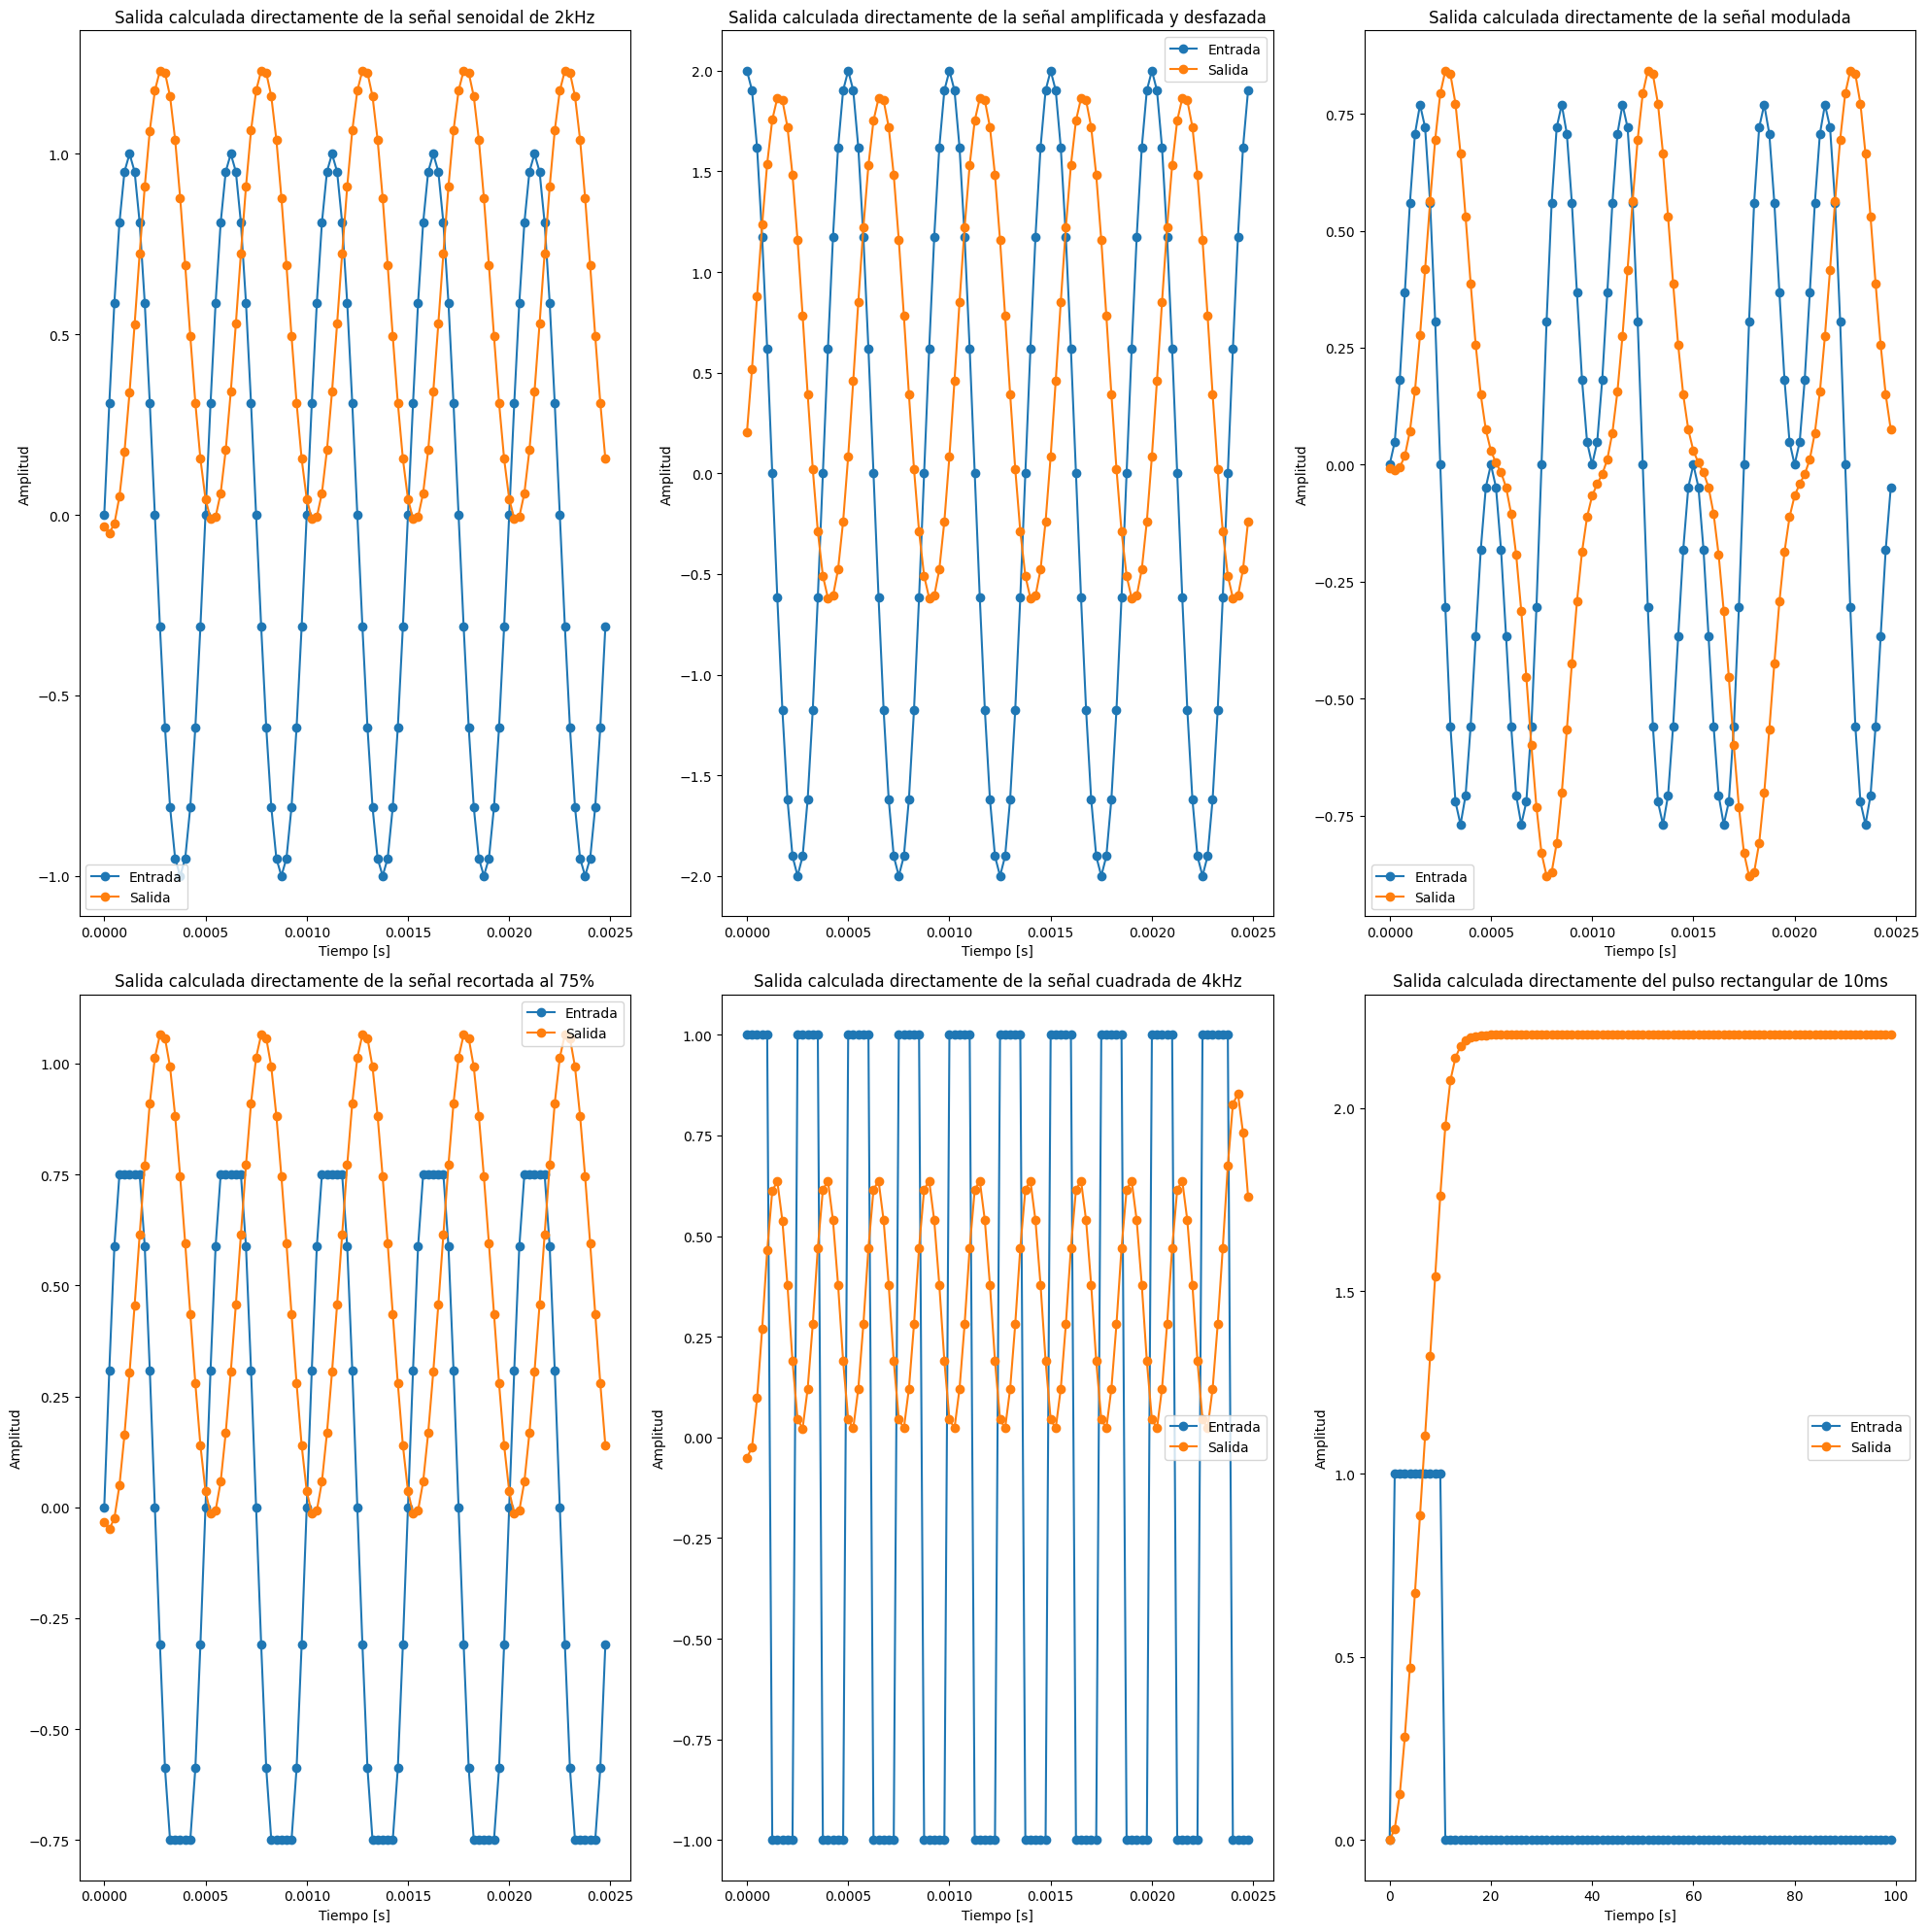



FRECUENCIA DE MUESTREO, TIEMPO DE SIMULACION, POTENCIAS Y ENERGIAS DEL EJERCICIO 1 (ITEM b)

Señal senoidal de 2kHz
Frecuancia de muestreo: fs =  40000
Tiempo de simulación: t =  0.002475
Potencia de la salida generada:  0.5676581630332274
Señal senoidal amplificada y desfazada

Frecuancia de muestreo: fs =  40000
Tiempo de simulación: t =  0.002475
Potencia de la salida generada:  1.1718925311079296
Señal modulada

Frecuancia de muestreo: fs =  40000
Tiempo de simulación: t =  0.002475
Potencia de la salida generada:  0.24556330626976997
Señal recortada

Frecuancia de muestreo: fs =  40000
Tiempo de simulación: t =  0.002475
Potencia de la salida generada:  0.41871305256966956
Señal cuadrada

Frecuancia de muestreo: fs =  40000
Tiempo de simulación: t =  0.002475
Potencia de la salida generada:  0.17244848629763546
Pulso rectangular de 10ms

Frecuancia de muestreo: fs =  40000


TypeError: 'numpy.float64' object is not iterable

In [32]:
# ------------------------------- EJERCICIO 1 -------------------------------

# Coeficientes del sistema (ecuacion de diferencias dada en el enunciado)

b = [0.03, 0.05, 0.03]  # Coeficientes de entrada x[n]
a = [1, -1.5, 0.5]        # Coeficientes de salida y[n]. El signo inverido es para lfilter

""" ITEM a """

# Graficos de las señales de salida de cada una de las señales generadas en el TS1

# Llamo a mis funciones del TS1
# Señales del TS1
t1, x1 = mi_funcion_sen(1, 0, 2000, 0, 100, fs) # Funcion senoidal original del TS1
t2, x2 = mi_funcion_sen(2, 0, 2000, np.pi/2, 100, fs) # Misma funcion amplificada y desfazada en pi/2
t3, x3 = mi_funcion_sen_modulada(1, 0, 2000, 0, 100, fs) # Funcion senoidal original modulada por otra
t4, x4 = mi_funcion_sen_recortada(1, 0, 2000, 0, 100, fs) # Funcion original recortada al 75% de su amplitud
t5, x5 = mi_funcion_cuadrada(4000, fs, 100, 0, 0) # Funcion cuadrada creada con SciPy
x6 = mi_funcion_pulso(1, 11, 100, 1) # Funcion pulso de 10ms

# Paso a mis funciones del TS1 por la ecuacion en diferencias
# Simulaciones

y1 = simular(x1)
y2 = simular(x2)
y3 = simular(x3)
y4 = simular(x4)
y5 = simular(x5)
y6 = simular(x6)

# Grafico la señal de salida de cada una se las funciones del TS1
fig, axes = plt.subplots(2, 3, figsize=(20, 20))  # Tamaño de la figura: ancho=20, alto=20

# Señal sinusoidal de 2kHz
plt.subplot(2, 3, 1)
plt.plot(t1, x1, 'o-', label = 'Entrada')
plt.plot(t1, y1, 'o-', label = 'Salida')
plt.title('Salida calculada directamente de la señal senoidal de 2kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()

# Señal amplificada y desfazada
plt.subplot(2, 3, 2)
plt.plot(t2, x2, 'o-', label = 'Entrada')
plt.plot(t2, y2, 'o-', label = 'Salida')
plt.title('Salida calculada directamente de la señal amplificada y desfazada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()

# Señal modulada
plt.subplot(2, 3, 3)
plt.plot(t3, x3, 'o-', label = 'Entrada')
plt.plot(t3, y3, 'o-', label = 'Salida')
plt.title('Salida calculada directamente de la señal modulada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()

# Señal recortada al 75%
plt.subplot(2, 3, 4)
plt.plot(t4, x4, 'o-', label = 'Entrada')
plt.plot(t4, y4, 'o-', label = 'Salida')
plt.title('Salida calculada directamente de la señal recortada al 75%')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()

# Señal cuadrada de 4kHz
plt.subplot(2, 3, 5)
plt.plot(t5, x5, 'o-', label = 'Entrada')
plt.plot(t5, y5, 'o-', label = 'Salida')
plt.title('Salida calculada directamente de la señal cuadrada de 4kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()

# Pulso rectangular de 10ms
plt.subplot(2, 3, 6)
plt.plot(x6, 'o-', label = 'Entrada')
plt.plot(y6, 'o-', label = 'Salida')
plt.title('Salida calculada directamente del pulso rectangular de 10ms')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()

plt.tight_layout()
plt.show()

# CALCULO LA POTENCIA O ENERGIA 
print("\n\nFRECUENCIA DE MUESTREO, TIEMPO DE SIMULACION, POTENCIAS Y ENERGIAS DEL EJERCICIO 1 (ITEM b)\n")

print("Señal senoidal de 2kHz")
print("Frecuancia de muestreo: fs = ", fs)
t1 = max(t1)
print("Tiempo de simulación: t = ", t1)
p1 = calcular_potencia(y1)
print("Potencia de la salida generada: ", p1)

print("Señal senoidal amplificada y desfazada")
print("\nFrecuancia de muestreo: fs = ", fs)
t2 = max(t2)
print("Tiempo de simulación: t = ", t2)
p2 = calcular_potencia(y2)
print("Potencia de la salida generada: ", p2)

print("Señal modulada")
print("\nFrecuancia de muestreo: fs = ", fs)
t3 = max(t3)
print("Tiempo de simulación: t = ", t3)
p3 = calcular_potencia(y3)
print("Potencia de la salida generada: ", p3)

print("Señal recortada")
print("\nFrecuancia de muestreo: fs = ", fs)
t4 = max(t4)
print("Tiempo de simulación: t = ", t4)
p4 = calcular_potencia(y4)
print("Potencia de la salida generada: ", p4)

print("Señal cuadrada")
print("\nFrecuancia de muestreo: fs = ", fs)
t5 = max(t5)
print("Tiempo de simulación: t = ", t5)
p5 = calcular_potencia(y5)
print("Potencia de la salida generada: ", p5)

print("Pulso rectangular de 10ms")
print("\nFrecuancia de muestreo: fs = ", fs)
t6 = max(t6)
print("Tiempo de simulación: t = ", t6)
p6 = calcular_energia(y6)
print("Energía de la salida generada: ", p6)

In [ ]:
""" ITEM b """
# Respuesta al impulso h[n]

# Hago la convolucion entre la señal y el impulso --> y eso me genera la nueva salida y[n]

# Llamo a mi funcion impulso
h = respuesta_impulso(a, b)

yy1 = np.convolve(x1, h)
yy2 = np.convolve(x2, h)
yy3 = np.convolve(x3, h)
yy4 = np.convolve(x4, h)
yy5 = np.convolve(x5, h)
yy6 = np.convolve(x6, h)

# Vector de tiempo para convolución (mismo fs, pero puede tener más muestras)
t_conv1 = np.arange(len(yy1)) / fs
t_conv2 = np.arange(len(yy2)) / fs
t_conv3 = np.arange(len(yy3)) / fs
t_conv4 = np.arange(len(yy4)) / fs
t_conv5 = np.arange(len(yy5)) / fs
dt = 1/fs
t_yy6 = np.arange(len(yy6)) * dt
t_x6 = np.arange(len(x6)) * dt

# Grafico --> deberia darme igual que lo calculado a traves de la ecuacion en diferencias
fig, axes = plt.subplots(2, 3, figsize=(20, 20))  # Tamaño de la figura: ancho=20, alto=20

plt.subplot(2, 3, 1)
plt.plot(t_conv1, yy1, 'x-', label='Salida')
plt.plot(t1, x1, 'o-', label='Entrada')
plt.title('Salida calculada indirectamente de la señal senoidal de 2kHz')
plt.xlabel('Tiempo [s]')
plt.xlim(0, max(t1))
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(t_conv2, yy2, 'x-', label = 'Salida')
plt.plot(t2,x2, 'o-', label = 'Entrada')
plt.title('Salida calculada indirectamente de la señal amplificada y desfazada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.xlim(0, max(t2))
plt.legend()

plt.subplot(2, 3, 3)
plt.plot(t_conv3, yy3, 'x-', label = 'Salida')
plt.plot(t3, x3, 'o-', label = 'Entrada')
plt.title('Salida calculada indirectamente de la señal modulada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.xlim(0, max(t3))
plt.legend()

plt.subplot(2, 3, 4)
plt.plot(t_conv4, yy4, 'x-', label = 'Salida')
plt.plot(t4, x4, 'o-', label = 'Entrada')
plt.title('Salida calculada indirectamente de la señal recortada al 75%')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.xlim(0, max(t4))
plt.legend()

plt.subplot(2, 3, 5)
plt.plot(t_conv5, yy5, 'x-', label = 'Salida')
plt.plot(t5, x5, 'o-', label = 'Entrada')
plt.title('Salida calculada indirectamente de la señal cuadrada de 4kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.xlim(0, max(t5))
plt.legend()

plt.subplot(2, 3, 6)
plt.plot(t_yy6, yy6, 'x-', label = 'Salida')
plt.plot(t_x6, x6, 'o-', label = 'Entrada')
plt.title('Salida calculada indirectamente del pulso rectangular de 10ms')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.xlim(0, max(t_x6))
plt.legend()

plt.tight_layout()
plt.show()

# CALCULO LA POTENCIA O ENERGIA
print("\n\nFRECUENCIA DE MUESTREO, TIEMPO DE SIMULACION, POTENCIAS Y ENERGIAS DEL EJERCICIO 1 (ITEM b)\n")

print("Señal senoidal de 2kHz")
print("Frecuancia de muestreo: fs = ", fs)
t1 = max(t_conv1)
print("Tiempo de simulación: t = ", t1)
p1 = calcular_potencia(yy1)
print("Potencia de la salida generada: ", p1)

print("Señal senoidal amplificada y desfazada")
print("\nFrecuancia de muestreo: fs = ", fs)
t2 = max(t_conv2)
print("Tiempo de simulación: t = ", t2)
p2 = calcular_potencia(yy2)
print("Potencia de la salida generada: ", p2)

print("Señal modulada")
print("\nFrecuancia de muestreo: fs = ", fs)
t3 = max(t_conv3)
print("Tiempo de simulación: t = ", t3)
p3 = calcular_potencia(yy3)
print("Potencia de la salida generada: ", p3)

print("Señal recortada")
print("\nFrecuancia de muestreo: fs = ", fs)
t4 = max(t_conv4)
print("Tiempo de simulación: t = ", t4)
p4 = calcular_potencia(yy4)
print("Potencia de la salida generada: ", p4)

print("Señal cuadrada")
print("\nFrecuancia de muestreo: fs = ", fs)
t5 = max(t_conv5)
print("Tiempo de simulación: t = ", t5)
p5 = calcular_potencia(yy5)
print("Potencia de la salida generada: ", p5)

print("Pulso rectangular de 10ms")
print("\nFrecuancia de muestreo: fs = ", fs)
t6 = max(t_yy6)
print("Tiempo de simulación: t = ", t6)
p6 = calcular_energia(yy6)
print("Energía de la salida generada: ", p6)

2) <font color=red><u> **Respuesta al impulso y verificación de la salida mediante convolución</u><font>**

   En este segundo ejercicio se estudiaron dos sistemas definidos por ecuaciones en diferencias con retardos de 10 muestras.
$$ 
y[n] = x[n] + 3 \cdot x[n - 10] \quad \text{(1)}
$$
$$
y[n] = x[n] + 3 \cdot y[n-10] \quad \text{(2)}
$$

- El primero corresponde a un sistema no recursivo, ya que la salida depende únicamente de valores presentes y pasados de la entrada. Su respuesta al impulso resultó finita, compuesta por dos pulsos separados en el tiempo y ubicados en $n = 0$ y $n = 10$. En este caso, $h[n]$ solo depende de $x[n]$ y de $x[n - 1]$, entonces, la respuesta al impulso tiene dos valores no nulos, y luego todo es cero, por lo que se dice que es finita. 
- El segundo es un sistema recursivo, ya que la salida depende de los valores pasados de sí misma. En este caso, la respuesta al impulso es infinita y mostró un patrón periódico debido a la realimentación. Se dice que la respuesta al impulso es infinita porque $y[n]$ depende de si misma en instantes anteriores, entonces si aplicamos el impulso unitario $x[n] = \delta[n]$, la salida nunca se hace cero, sino que decae exponencialmente pero sigue indefinidamente. 


In [ ]:
# Defino los parametros del ejercicio
# Voy a usar la misma funcion seno definida en el ejercicio anterior (x1)

# Coeficientes de las ecuaciones en diferencias dadas
# Ecuacion 1
b1 = [1,0,0,0,0,0,0,0,0,0,3] # Coeficientes de entrada x[n]
a1 = [1.0]
#Ecuacion 2
b2 = [1.0] # Coeficientes de entrada x[n]
a2 = [1,0,0,0,0,0,0,0,0,0,-3] # Coeficientes de salida y[n]

# Calculo la respuesta al impulso

# Ecuacion 1
h1 = respuesta_impulso(a1, b1)

# Ecuacion 2
h2 = respuesta_impulso(a2, b2)

# Respuesta al impulso de ambos sistemas
plt.figure(figsize=(20,20))

# Ecuación 1
plt.subplot(1, 2, 1)
plt.plot(h1, 'o-')
plt.title("Respuesta al impulso - Ecuación 1")
plt.xlabel("n")
plt.ylabel("h1[n]")

# Ecuación 2
plt.subplot(1, 2, 2)
plt.plot(h2, 'o-')  # muestro primeras 100 muestras
plt.title("Respuesta al impulso - Ecuación 2")
plt.xlabel("n")
plt.ylabel("h2[n]")

plt.tight_layout()
plt.show()

Posteriormente, se calculo la salida de cada una de las ecuaciones dadas mediante la convolución
$$
y[n] = \sum_{k = -\infty}^{\infty}x[k] \cdot h[n-k]
$$

In [ ]:
# Calculo la salida de ambos sistemas
# Convolusiono
# Para la ecuacion 1
y1 = np.convolve(x1, h1)

# Para la ecuacion 2
y2 = np.convolve(x1, h2)

# Vector de tiempo para convolución (mismo fs, pero puede tener más muestras)
t_conv1 = np.arange(len(y1)) / fs
t_conv2 = np.arange(len(y2)) / fs

# Grafico las soluciones
fig, axes = plt.subplots(1, 2, figsize=(20, 20))

# Ecuacion 1
plt.subplot(1, 2, 1)
plt.plot(t_conv1, y1, 'x-', label = 'Salida')
plt.plot(t1, x1, 'o-', label = 'Entrada')
plt.title('Salida de la primera ecuacion calculada a traves de h[n]')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.xlim(0, max(t1))
plt.legend()

# Ecuacion 2
plt.subplot(1, 2, 2)
plt.plot(t_conv2, y2, 'x-', label = 'Salida')
plt.plot(t1, x1, 'o-', label = 'Entrada')
plt.title('Salida de la segunda ecuacion calculada a traves de h[n]')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.xlim(0, max(t1))
plt.legend()

plt.tight_layout()
plt.show()


# <u>**Conclusiones**</u>

En el presente trabajo se estudiaron distintos sistemas lineales e invariantes en el tiempo (*LTI*) representados mediante ecuaciones en diferencias, evaluando tanto su comportamiento teórico como su implementación práctica en el dominio discreto. 

En primer lugar, se analizó un sistema de segundo orden cuya salida se obtuvo de dos maneras: aplicando directamente la ecuación en diferencias y mediante la convolución con la respuesta al impulso. En ambos casos, se obtuvieron resultados equivalentes, lo que confirmó la propiedad fundamental de los sistemas *LTI*: **la salida puede determinarse de manera indistinta a partir de la ecuación en diferencias o de la convolución con la respuesta al impulso**. 

Posteriormente, se estudiaron dos sistemas con retardos de 10 muestras, uno no recursivo y otro recursivo. Se observó que: 
- El sistema **no recursivo** (*Ecuacion 1*) presentó una respuesta al impulso finita, con dos pulsos separados en el tiempo.
- El sistema **recursivo** (*Ecuación 2*) mostró una respuesta al impulso infinita, con réplicas periódicas que aumentan de ampliitud debido a la realimentación.

En ambos casos, la simulación con una señal senoidal permitió apreciar cómo los retardos introducen modificaciones en la salida, ya sea como superposicion de señales desplazadas (en el no recursivo) o como repeticiones indefinidas (en el recursivo).

Además, se calculó la energía en señales de duración finita y la potencia en señales periódicas, lo cual permitió cuantificar los efectos de cada sistema sobre distintas entradas y proporcionó una caracterización mas completa de su comportamiento.

En términos generales, el trabajo permitió: 
- Validar experimentalmente conceptos teóricos fundamentales de los sistemas *LTI*.
- Comparar la influencia de la recursividad y los retardos en la respuesta temporal y espectral de los sistemas.
- Fortalecer el vínculo entre la teoría y la práctica, mediante la implementación en Python y el análisis de los resultados obtenidos.

En conclusión, el estudio realizado refuerza la importancia de la representación mediante **ecuaciones en diferencias** y la **respuesta al impulso** como herramientas centrales para el análisis de sistemas discretos, y proporciona comprensión práctica de cómo las estructuras con o sin realimentación afectan la salida de señales causales.

# <u>**Autoevaluación del aprendizaje**</u>

Para concluir con el informe se realizó una autoevaluacion del aprendizaje.

Durante la resolución de esta tarea aprendí a aplicar la ecuación en diferencias para modelar un sistema *LTI* en el dominio discreto y a verificar la equivalencia entre este enfoque y la convolución con la respuesta al impulso. 

Me quedó claro que la salida de un sistema *LTI* puede calcularse indistintamente mediante la ecuación en diferencias o a partir de la convolución con el impulso, y que la retroalimentación es la característica que determina si un sistema tendrá respuesta infinita. Lo que me sigue costando es interpretar como los retardos modifican la salida en el dominio de la frecuencia y relacionar mejor la simulación en el tiempo con su análisis esprectral. 

Para este trabajo utilicé la ayuda de la *IA*. Use *Copilot* para que me ayude con la programación de los códigos. Y por otro lado usé *ChatGPT* para conceptos teóricos que todavia no tenía claros. 

Para finalizar con la autoevaluación, siento que las tareas semanales me sirven para reforzar los conceptos teóricos vistos en clase, pero de todas maneras me gustaría que nos den mas base para poder realizarlos, ya que me pasó con la *TS1* y ahora con la *TS2* que siempre tengo que recurrir a paginas de internet, *IA*, videos de youtube, libros, etc. porque me faltan conocimientos teóricos, sobre todo en los resultados que debería esperar obtener. 